# Tarea 1: Predicción de resultados del fútbol uruguayo

In [176]:
# %pip install pandas numpy matplotlib scikit-learn

In [177]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

--- 
### 1. Carga del Dataset y Descripción de Atributos

In [178]:
DATASET_FILE = "./futbol_uruguayo.csv" 

dataset = pd.read_csv(DATASET_FILE)
dataset.head()

,home,away,date,gh,ga,full_time,competition,home_ident,away_ident,home_country,away_country,home_code,away_code,home_continent,away_continent,continent,level
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,uruguay,Bella Vista (Uruguay),Defensor Sporting (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,uruguay,CA Penarol (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
2,Montevideo Wanderers,Racing Club,1932-03-05,3.0,0.0,F,uruguay,Montevideo Wanderers (Uruguay),Racing Club (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
3,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1.0,0.0,F,uruguay,Central Espanol (Uruguay),Rampla Juniors Futbol Club (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
4,Nacional,Institucion Atletica Sud America,1932-03-05,2.0,0.0,F,uruguay,Nacional (Uruguay),Institucion Atletica Sud America (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national


#### Descripción de los atributos:

| Atributo | Descripción |
| :--- | :--- |
| **`home`** | Nombre del equipo local (no necesariamente único) |
| **`away`** | Nombre del equipo visitante (no necesariamente único) |
| **`date`** | Fecha del partido |
| **`gh`** | Goles del equipo local (incluyendo tiempo extra y penales) |
| **`ga`** | Goles del equipo visitante (incluyendo tiempo extra y penales) |
| **`full_time`** | "F"=el partido terminó en 90', "E"=tiempo extra, "P"=penales |
| **`competition`** | Nombre del país de la liga o nombre de la competición int. |
| **`home_ident`** | Identificador único del equipo local |
| **`away_ident`** | Identificador único del equipo visitante |
| **`home_country`** | País del equipo local |
| **`away_country`** | País del equipo visitante |
| **`home_code`** | Código de país del equipo local |
| **`away_code`** | Código de país del equipo visitante |
| **`home_continent`** | Continente del equipo local |
| **`away_continent`** | Continente del equipo visitante |
| **`continent`** | Continente de la competición |
| **`level`** | "national"= liga local, "international"= copa internacional |

--- 
### 2. Definición de la Variable Objetivo (`ganador`)

El objetivo del modelo es predecir el resultado final de un partido de fútbol, clasificándolo en una de tres categorías posibles: victoria local, victoria visitante o empate.

Dado que el dataset original no incluye directamente una columna de resultado, se deduce la variable objetivo **`ganador`** mediante la comparación de los goles anotados por el equipo local (`gh`) y el visitante (`ga`):

* Si $\text{gh} > \text{ga} \implies$ **`L`**
* Si $\text{ga} > \text{gh} \implies$ **`V`**
* Si $\text{gh} == \text{ga} \implies$ **`E`**

Concretado lo anterior, la información que proveen los atributos "gh" y "ga" ya se ve contemplada por la variable objetivo. Por lo tanto, su presencia en el dataset no agrega significancia al entrenamiento del modelo y se deben remover ambos atributos del dataset.

In [179]:
dataset["ganador"] = np.select(
    [
        dataset["gh"] > dataset["ga"],
        dataset["gh"] < dataset["ga"],
        dataset["gh"] == dataset["ga"],
    ],
    [
        "L",
        "V",
        "E",
    ],
    default="sin_dato",
)

dataset.head(10)

,home,away,date,gh,ga,full_time,competition,home_ident,away_ident,home_country,away_country,home_code,away_code,home_continent,away_continent,continent,level,ganador
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,uruguay,Bella Vista (Uruguay),Defensor Sporting (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,V
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,uruguay,CA Penarol (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,E
2,Montevideo Wanderers,Racing Club,1932-03-05,3.0,0.0,F,uruguay,Montevideo Wanderers (Uruguay),Racing Club (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
3,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1.0,0.0,F,uruguay,Central Espanol (Uruguay),Rampla Juniors Futbol Club (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
4,Nacional,Institucion Atletica Sud America,1932-03-05,2.0,0.0,F,uruguay,Nacional (Uruguay),Institucion Atletica Sud America (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
5,Nacional,River Plate,1932-03-12,3.0,3.0,F,uruguay,Nacional (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,E
6,Defensor Sporting,Racing Club,1932-03-12,6.0,0.0,F,uruguay,Defensor Sporting (Uruguay),Racing Club (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
7,CA Penarol,Institucion Atletica Sud America,1932-03-12,4.0,0.0,F,uruguay,CA Penarol (Uruguay),Institucion Atletica Sud America (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
8,Rampla Juniors Futbol Club,Bella Vista,1932-03-12,3.0,1.0,F,uruguay,Rampla Juniors Futbol Club (Uruguay),Bella Vista (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,L
9,Montevideo Wanderers,Central Espanol,1932-03-12,1.0,1.0,F,uruguay,Montevideo Wanderers (Uruguay),Central Espanol (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national,E


--- 
### 3. Selección de Atributos

En esta etapa del preprocesamiento se realiza una selección de los atributos del dataset con el objetivo de maximizar la capacidad de aprendizaje del modelo en la clasificación de las instancias. Para ello, se examina cada atributo de forma individual para evaluar si contribuye de manera significativa al entrenamiento o si, dadas sus características, puede ser removido sin perjudicar el desempeño.

* **Atributos constantes:** No contribuyen al aprendizaje del modelo debido a que mantienen el mismo valor para todas las instancias del dataset (varianza cero).
* **Atributos redundantes:** Representan valores equivalentes dentro del dataset, por lo que basta con conservar uno de ellos.

#### A. Detección de Atributos Constantes

In [180]:
# Detección de Atributos Constantes
constantes = dataset.nunique(dropna=False)[dataset.nunique(dropna=False) == 1]
print("Atributos constantes detectados:")
print(constantes)

# Eliminar todas las columnas con un solo valor único
dataset = dataset.loc[:, dataset.nunique() > 1]

Atributos constantes detectados:
competition       1
home_country      1
away_country      1
home_code         1
away_code         1
home_continent    1
away_continent    1
continent         1
level             1
dtype: int64


Los atributos constantes son los siguientes:
* `competition`, `home_country`, `away_country` (Todos refieren a Uruguay).
* `home_code`, `away_code` (Código constante `UY`).
* `home_continent`, `away_continent`, `continent` (Todos refieren a `South America`).
* `level` (Constante con el valor `national`).

Estos atributos no serán incluidos en los conjuntos de entrenamiento y evaluación.

#### B. Detección de Atributos Redundantes

In [181]:
# Verificar cuántos identificadores tiene cada nombre de equipo, y viceversa
home_name_to_id = dataset.groupby("home")["home_ident"].nunique(dropna=False)
home_id_to_name = dataset.groupby("home_ident")["home"].nunique(dropna=False)

away_name_to_id = dataset.groupby("away")["away_ident"].nunique(dropna=False)
away_id_to_name = dataset.groupby("away_ident")["away"].nunique(dropna=False)

print(f"Cada valor de home se corresponde a un solo valor de home_ident, y viceversa: ", (home_name_to_id == 1).all()  & (home_id_to_name == 1).all())
print(f"Cada valor de away se corresponde a un solo valor de away_ident, y viceversa: ", (away_name_to_id == 1).all()  & (away_id_to_name == 1).all())

dataset = dataset.drop(columns=['home_ident', 'away_ident'])

Cada valor de home se corresponde a un solo valor de home_ident, y viceversa:  True
Cada valor de away se corresponde a un solo valor de away_ident, y viceversa:  True


Existe una correspondencia 1:1, mantener ambas variables introduciría información redundante. Elegimos quedarnos con `home` y `away` y se descartan sus identificadores (`home_ident` y `away_ident`).

#### C. Descomposición del atributo `date`

El atributo `date` se divide en los atributos `day`, `month` y `year` para representar sus componentes por separado. Esta transformación facilita que el modelo identifique patrones relacionados con el momento del año en que se disputó el partido, como diferencias entre meses, temporadas o períodos históricos. Además, evita tratar cada fecha completa como un valor independiente, lo que podría dificultar el aprendizaje. Una vez extraídos estos componentes, se debe remover el atributo `date` original para evitar mantener información redundante.

En el flujo final, este procedimiento será ejecutado dentro del `Pipeline`.

In [182]:
dataset["date"] = pd.to_datetime(dataset["date"])
dataset["day_of_week"] = dataset["date"].dt.day_name()
dataset["month"] = dataset["date"].dt.month
dataset['year'] = dataset['date'].dt.year

---
### 4. Análisis de Balance y Estratificación:

In [183]:
# Cálculo de la dispersión de instancias respecto a las clases
porcentajes = dataset["ganador"].value_counts(normalize=True).mul(100).round(2)

instancias_L = float(porcentajes.iloc[0])
instancias_V = float(porcentajes.iloc[1])
instancias_E = float(porcentajes.iloc[2])

print(f"Porcentaje de instancias correspondientes a la clase L: ", instancias_L)
print(f"Porcentaje de instancias correspondientes a la clase V: ", instancias_V)
print(f"Porcentaje de instancias correspondientes a la clase E: ", instancias_E)

Porcentaje de instancias correspondientes a la clase L:  44.35
Porcentaje de instancias correspondientes a la clase V:  28.2
Porcentaje de instancias correspondientes a la clase E:  27.44


In [184]:
# Cálculo de la dispersión de instancias respecto a las clases
dataset["ganador"].value_counts(normalize=True).mul(100).round(2)

ganador
L    44.35
V    28.20
E    27.44
Name: proportion, dtype: float64

La distribución de la clase objetivo muestra las siguientes proporciones:
* **`L`**: **44.35%**
* **`V`**: **28.20%**
* **`E`**: **27.44%**

Aunque existe un predominio de las victorias locales, la distribución no presenta un desbalance crítico (como ocurriría en escenarios con clases minoritarias $< 5\%$), por lo que no se requiere la aplicación de técnicas de mitigación como *SMOTE* o *undersampling*. 

Sin embargo, para evitar que una división puramente aleatoria, se aplica un muestreo estratificado (`stratify=dataset_Y`). De esta manera, se garantiza que tanto el conjunto de entrenamiento como el de evaluación mantengan proporciónes similares a las originales del dataset para cada clase.

In [185]:
dataset.head(20)

,home,away,date,gh,ga,full_time,ganador,day_of_week,month,year
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,V,Saturday,3,1932
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,E,Saturday,3,1932
2,Montevideo Wanderers,Racing Club,1932-03-05,3.0,0.0,F,L,Saturday,3,1932
3,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1.0,0.0,F,L,Saturday,3,1932
4,Nacional,Institucion Atletica Sud America,1932-03-05,2.0,0.0,F,L,Saturday,3,1932
5,Nacional,River Plate,1932-03-12,3.0,3.0,F,E,Saturday,3,1932
6,Defensor Sporting,Racing Club,1932-03-12,6.0,0.0,F,L,Saturday,3,1932
7,CA Penarol,Institucion Atletica Sud America,1932-03-12,4.0,0.0,F,L,Saturday,3,1932
8,Rampla Juniors Futbol Club,Bella Vista,1932-03-12,3.0,1.0,F,L,Saturday,3,1932
9,Montevideo Wanderers,Central Espanol,1932-03-12,1.0,1.0,F,E,Saturday,3,1932


---
### 5. Atributos nuevos

Se definen atributos recientes de victorias, empates y goles para local y visitante.

Estos atributos no se calculan sobre todo el dataset antes del split temporal. Primero se separa entrenamiento y evaluación por año, y luego:

- en entrenamiento, cada partido usa solo partidos anteriores del propio conjunto de entrenamiento
- en evaluación, cada partido usa solo el historial disponible hasta 2023, para evitar data leakage

In [204]:
columnas_atributos_derivados = [
    'victoria_local',
    'victoria_visitante',
    'empate',
    'local_wins_last_10',
    'visit_wins_last_10',
    'local_draws_last_10',
    'visit_draws_last_10',
    'local_goals_scored_last_10',
    'local_goals_conceded_last_10',
    'visit_goals_scored_last_10',
    'visit_goals_conceded_last_10',
    'local_points_last_10',
    'visit_points_last_10',
    'form_diff_last_10',
]

dataset = dataset.drop(
    columns=[columna for columna in columnas_atributos_derivados if columna in dataset.columns],
    errors='ignore'
)
dataset = dataset.sort_values('date').reset_index(drop=True)

def agregar_atributos_recientes_secuenciales(df_partidos):
    df_partidos = df_partidos.sort_values('date').reset_index(drop=True).copy()

    df_partidos['victoria_local'] = (df_partidos['ganador'] == 'L').astype(int)
    df_partidos['victoria_visitante'] = (df_partidos['ganador'] == 'V').astype(int)
    df_partidos['empate'] = (df_partidos['ganador'] == 'E').astype(int)

    df_partidos['local_wins_last_10'] = (
        df_partidos.groupby('home')['victoria_local']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['visit_wins_last_10'] = (
        df_partidos.groupby('away')['victoria_visitante']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['local_draws_last_10'] = (
        df_partidos.groupby('home')['empate']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['visit_draws_last_10'] = (
        df_partidos.groupby('away')['empate']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['local_goals_scored_last_10'] = (
        df_partidos.groupby('home')['gh']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['local_goals_conceded_last_10'] = (
        df_partidos.groupby('home')['ga']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['visit_goals_scored_last_10'] = (
        df_partidos.groupby('away')['ga']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )
    df_partidos['visit_goals_conceded_last_10'] = (
        df_partidos.groupby('away')['gh']
        .transform(lambda serie: serie.shift(1).rolling(10, min_periods=1).sum())
        .fillna(0)
        .astype(int)
    )

    return df_partidos

def construir_resumen_historico_entrenamiento(df_entrenamiento):
    ultimos_local = df_entrenamiento.sort_values('date').groupby('home').tail(10).copy()
    ultimos_visitante = df_entrenamiento.sort_values('date').groupby('away').tail(10).copy()

    resumen_local = (
        ultimos_local.assign(
            victoria_local=(ultimos_local['ganador'] == 'L').astype(int),
            empate=(ultimos_local['ganador'] == 'E').astype(int),
        )
        .groupby('home', as_index=False)
        .agg(
            local_wins_last_10=('victoria_local', 'sum'),
            local_draws_last_10=('empate', 'sum'),
            local_goals_scored_last_10=('gh', 'sum'),
            local_goals_conceded_last_10=('ga', 'sum'),
        )
    )

    resumen_visitante = (
        ultimos_visitante.assign(
            victoria_visitante=(ultimos_visitante['ganador'] == 'V').astype(int),
            empate=(ultimos_visitante['ganador'] == 'E').astype(int),
        )
        .groupby('away', as_index=False)
        .agg(
            visit_wins_last_10=('victoria_visitante', 'sum'),
            visit_draws_last_10=('empate', 'sum'),
            visit_goals_scored_last_10=('ga', 'sum'),
            visit_goals_conceded_last_10=('gh', 'sum'),
        )
    )

    return resumen_local, resumen_visitante

# dataset[['date', 'home', 'away', 'gh', 'ga', 'ganador']].head(15)
dataset.tail(15)


,home,away,date,gh,ga,full_time,ganador,day_of_week,month,year
15192,CA Juventud,Danubio,2025-06-21,3.0,1.0,F,L,Saturday,6,2025
15193,CA Penarol,Montevideo Wanderers,2025-06-22,2.0,0.0,F,L,Sunday,6,2025
15194,River Plate,Liverpool,2025-06-22,2.0,1.0,F,L,Sunday,6,2025
15195,Racing Club,CA Progreso,2025-06-22,3.0,0.0,F,L,Sunday,6,2025
15196,Defensor Sporting,CA Cerro,2025-06-22,2.0,1.0,F,L,Sunday,6,2025
15197,Cerro Largo FC,Plaza Colonia,2025-06-23,0.0,1.0,F,V,Monday,6,2025
15198,Boston River,Torque FC,2025-06-23,2.0,1.0,F,L,Monday,6,2025
15199,CA Penarol,CA Cerro,2025-06-28,2.0,0.0,F,L,Saturday,6,2025
15200,Boston River,Miramar Misiones,2025-06-28,1.0,2.0,F,V,Saturday,6,2025
15201,Liverpool,Montevideo Wanderers,2025-06-28,1.0,2.0,F,V,Saturday,6,2025


---
### 5. División del Conjunto de Datos (`train_test_split`)

Se divide el conjunto `dataset` de la siguiente forma:

- entrenamiento: partidos jugados hasta el año 2023 inclusive
- evaluación: partidos jugados en 2024 y 2025

Este corte se hace antes de construir los atributos recientes, para que las variables derivadas del resultado no usen información futura del conjunto de evaluación.

In [205]:
# Se separa primero en entrenamiento y evaluación para evitar leakage temporal

dataset = dataset.sort_values(by='date').reset_index(drop=True)

df_entrenamiento = dataset[dataset['year'] <= 2023].copy()
df_evaluacion = dataset[dataset['year'] > 2023].copy()

# En entrenamiento, cada partido usa solo partidos anteriores del mismo conjunto
df_entrenamiento = agregar_atributos_recientes_secuenciales(df_entrenamiento)

# En evaluación, los atributos se construyen usando solo el historial disponible en entrenamiento
resumen_local_train, resumen_visitante_train = construir_resumen_historico_entrenamiento(df_entrenamiento)

df_evaluacion = (
    df_evaluacion
    .merge(resumen_local_train, on='home', how='left')
    .merge(resumen_visitante_train, on='away', how='left')
)

columnas_atributos_recientes = [
    'local_wins_last_10',
    'visit_wins_last_10',
    'local_draws_last_10',
    'visit_draws_last_10',
    'local_goals_scored_last_10',
    'local_goals_conceded_last_10',
    'visit_goals_scored_last_10',
    'visit_goals_conceded_last_10',
]

df_evaluacion[columnas_atributos_recientes] = (
    df_evaluacion[columnas_atributos_recientes]
    .fillna(0)
    .astype(int)
)

columnas_descartar_modelo = [
    'date', 'ganador', 'gh', 'ga', 'year',
    'victoria_local', 'victoria_visitante', 'empate'
]

X_train = df_entrenamiento.drop(
    columns=[columna for columna in columnas_descartar_modelo if columna in df_entrenamiento.columns]
)
Y_train = df_entrenamiento['ganador']

X_test = df_evaluacion.drop(
    columns=[columna for columna in columnas_descartar_modelo if columna in df_evaluacion.columns]
)
Y_test = df_evaluacion['ganador']

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Evaluación):    {X_test.shape}")
X_train.head(15)


Dimensiones de X_train (Entrenamiento): (14734, 13)
Dimensiones de X_test (Evaluación):    (473, 13)


,home,away,full_time,day_of_week,month,local_wins_last_10,visit_wins_last_10,local_draws_last_10,visit_draws_last_10,local_goals_scored_last_10,local_goals_conceded_last_10,visit_goals_scored_last_10,visit_goals_conceded_last_10
0,Bella Vista,Defensor Sporting,F,Saturday,3,0,0,0,0,0,0,0,0
1,CA Penarol,River Plate,F,Saturday,3,0,0,0,0,0,0,0,0
2,Montevideo Wanderers,Racing Club,F,Saturday,3,0,0,0,0,0,0,0,0
3,Central Espanol,Rampla Juniors Futbol Club,F,Saturday,3,0,0,0,0,0,0,0,0
4,Nacional,Institucion Atletica Sud America,F,Saturday,3,0,0,0,0,0,0,0,0
5,Nacional,River Plate,F,Saturday,3,1,0,0,1,2,0,1,1
6,Defensor Sporting,Racing Club,F,Saturday,3,0,0,0,0,0,0,0,3
7,CA Penarol,Institucion Atletica Sud America,F,Saturday,3,0,0,1,0,1,1,0,2
8,Rampla Juniors Futbol Club,Bella Vista,F,Saturday,3,0,0,0,0,0,0,0,0
9,Montevideo Wanderers,Central Espanol,F,Saturday,3,1,0,0,0,3,0,0,0


In [188]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer


numeric_features = [
    'month',
    'local_wins_last_10',
    'visit_wins_last_10',
    'local_draws_last_10',
    'visit_draws_last_10',
    'local_goals_scored_last_10',
    'local_goals_conceded_last_10',
    'visit_goals_scored_last_10',
    'visit_goals_conceded_last_10',
]
categorical_features = ['home', 'away', 'full_time', 'day_of_week']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(fill_value='missing', strategy='constant')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))],
)

preprocessing = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features),
    ],
)


pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state=62))
])

X_train.head()


,home,away,full_time,day_of_week,month,local_wins_last_10,visit_wins_last_10,local_draws_last_10,visit_draws_last_10,local_goals_scored_last_10,local_goals_conceded_last_10,visit_goals_scored_last_10,visit_goals_conceded_last_10
0,Bella Vista,Defensor Sporting,F,Saturday,3,0,0,0,0,0,0,0,0
1,CA Penarol,River Plate,F,Saturday,3,0,0,0,0,0,0,0,0
2,Montevideo Wanderers,Racing Club,F,Saturday,3,0,0,0,0,0,0,0,0
3,Central Espanol,Rampla Juniors Futbol Club,F,Saturday,3,0,0,0,0,0,0,0,0
4,Nacional,Institucion Atletica Sud America,F,Saturday,3,0,0,0,0,0,0,0,0


In [189]:
param_grid = {
    # Preprocesamiento numérico
    'preprocessing__numeric__imputer__strategy': [
        'mean',
        'median'
    ],
    # Árbol de decisión
    'model__max_depth': [
        3,
        6,
        10,
        15,
        None
    ],
    'model__criterion': [
        'gini', 'entropy'
    ],
    'model__class_weight': [
        None,
        'balanced'
    ],
    # Minima ganancia permitida para un atributo
    'model__min_impurity_decrease': [
        0.0,
        0.001,
        0.005,
        0.01,
        0.05
    ]
}

In [190]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cv_temporal = TimeSeriesSplit(n_splits=10)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_temporal,
    n_jobs=-1,
    refit=True
)

# GridSearchCV realiza internamente la validación cruzada
grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=62))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 6, ...], 'model__min_impurity_decrease': [0.0, 0.001, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cros

In [191]:
pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(
        criterion='entropy',
        min_impurity_decrease=0.001,
        class_weight='balanced',
        random_state=62
    ))
])

Naive Bayes.

En este seccion se realizará el entrenamiento en busqueda de los mejores hiperparametros para el algoritmo.

In [192]:
class NaiveBayes:
    """Naive Bayes categórico multiclase con suavizado m-estimate."""

    def __init__(self, m=1.0):
        self.m = m

    def fit(self, X, y):
        self.clases_ = sorted(y.unique())
        cantidad_total = len(y)

        self.log_prioris_ = {}
        self.tablas_categoricas_ = {}    # tablas_categoricas_[clase][columna][valor] = probabilidad
        self.respaldo_categoricas_ = {}  # probabilidad para valores no vistos en entrenamiento
        self.dominio_columnas_ = {columna: X[columna].unique().tolist() for columna in X.columns}

        for clase in self.clases_:
            mascara_clase = (y == clase)
            X_clase = X.loc[mascara_clase]
            cantidad_clase = mascara_clase.sum()
            self.log_prioris_[clase] = np.log(cantidad_clase / cantidad_total)

            self.tablas_categoricas_[clase] = {}
            self.respaldo_categoricas_[clase] = {}
            for columna in X.columns:
                dominio = self.dominio_columnas_[columna]
                probabilidad_uniforme = 1.0 / len(dominio)
                conteos = X_clase[columna].value_counts()

                tabla_columna = {
                    valor: (conteos.get(valor, 0) + self.m * probabilidad_uniforme) / (cantidad_clase + self.m)
                    for valor in dominio
                }
                self.tablas_categoricas_[clase][columna] = tabla_columna
                # Probabilidad para un valor jamás visto en entrenamiento (conteo = 0)
                self.respaldo_categoricas_[clase][columna] = (self.m * probabilidad_uniforme) / (cantidad_clase + self.m)

        return self

    def _log_verosimilitud(self, fila, clase):
        log_probabilidad = 0.0
        for columna, tabla_columna in self.tablas_categoricas_[clase].items():
            valor = fila[columna]
            log_probabilidad += np.log(tabla_columna.get(valor, self.respaldo_categoricas_[clase][columna]))
        return log_probabilidad

    def predict_log_proba(self, X):
        filas = [
            {
                clase: self.log_prioris_[clase] + self._log_verosimilitud(fila, clase)
                for clase in self.clases_
            }
            for _, fila in X.iterrows()
        ]
        return pd.DataFrame(filas, index=X.index)[self.clases_]

    def predict(self, X):
        log_probabilidades = self.predict_log_proba(X)
        return log_probabilidades.idxmax(axis=1)


In [193]:
# Se combinan atributos categóricos originales con los atributos discretos de forma reciente
atributos_naive_bayes = categorical_features + [
    'local_wins_last_10',
    'visit_wins_last_10',
    'local_draws_last_10',
    'visit_draws_last_10',
    'local_goals_scored_last_10',
    'local_goals_conceded_last_10',
    'visit_goals_scored_last_10',
    'visit_goals_conceded_last_10',
]

X_train_nb = X_train[atributos_naive_bayes].fillna('desconocido')
X_test_nb = X_test[atributos_naive_bayes].fillna('desconocido')

X_train_nb.head()


,home,away,full_time,day_of_week,local_wins_last_10,visit_wins_last_10,local_draws_last_10,visit_draws_last_10,local_goals_scored_last_10,local_goals_conceded_last_10,visit_goals_scored_last_10,visit_goals_conceded_last_10
0,Bella Vista,Defensor Sporting,F,Saturday,0,0,0,0,0,0,0,0
1,CA Penarol,River Plate,F,Saturday,0,0,0,0,0,0,0,0
2,Montevideo Wanderers,Racing Club,F,Saturday,0,0,0,0,0,0,0,0
3,Central Espanol,Rampla Juniors Futbol Club,F,Saturday,0,0,0,0,0,0,0,0
4,Nacional,Institucion Atletica Sud America,F,Saturday,0,0,0,0,0,0,0,0


In [194]:
naive_bayes = NaiveBayes(m=1.0)
naive_bayes.fit(X_train_nb, Y_train)

predicciones_nb = naive_bayes.predict(X_test_nb)
predicciones_nb.head()


0    L
1    V
2    V
3    V
4    E
dtype: object

In [195]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(Y_test, predicciones_nb))
print()
print(classification_report(Y_test, predicciones_nb))
print("Matriz de confusión (orden de clases:", naive_bayes.clases_, "):")
print(confusion_matrix(Y_test, predicciones_nb, labels=naive_bayes.clases_))


Accuracy: 0.4608879492600423

              precision    recall  f1-score   support

           E       0.36      0.26      0.30       132
           L       0.50      0.54      0.52       190
           V       0.47      0.54      0.50       151

    accuracy                           0.46       473
   macro avg       0.44      0.45      0.44       473
weighted avg       0.45      0.46      0.45       473

Matriz de confusión (orden de clases: ['E', 'L', 'V'] ):
[[ 34  52  46]
 [ 40 102  48]
 [ 20  49  82]]


---
### 6. Selección de Hiperparámetros con Cross-Validation

Se aplica **validación cruzada temporal** sobre el conjunto de **entrenamiento** (nunca sobre el conjunto de evaluación 2024-2025, para no filtrar información) con el objetivo de elegir el mejor valor del hiperparámetro `m` (suavizado m-estimate) del `NaiveBayes` propio.

* Valores de `m` evaluados: `[0.1, 0.5, 1, 2, 5, 10, 20, 50]`.
* Se usa `TimeSeriesSplit` con 5 particiones, respetando el orden temporal de los partidos.
* En cada partición se entrena con partidos anteriores y se valida con partidos posteriores.
* Métrica de selección: **F1-macro promedio** entre las particiones (pondera por igual a las 3 clases, sin favorecer a `L` por ser mayoritaria). También se registra el accuracy como referencia.


In [216]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score

valores_m = [0.1, 0.5, 1, 2, 5, 10, 20, 50]
cantidad_folds = 5

kf = TimeSeriesSplit(n_splits=cantidad_folds)

resultados_cv = []
for m in valores_m:
    f1_folds = []
    accuracy_folds = []
    for indice_train, indice_val in kf.split(X_train_nb):
        X_train_fold = X_train_nb.iloc[indice_train]
        X_val_fold = X_train_nb.iloc[indice_val]
        y_train_fold = Y_train.iloc[indice_train]
        y_val_fold = Y_train.iloc[indice_val]

        modelo_fold = NaiveBayes(m=m)
        modelo_fold.fit(X_train_fold, y_train_fold)
        predicciones_fold = modelo_fold.predict(X_val_fold)

        f1_folds.append(f1_score(y_val_fold, predicciones_fold, average='macro'))
        accuracy_folds.append(accuracy_score(y_val_fold, predicciones_fold))

    resultados_cv.append({
        'm': m,
        'f1_macro_promedio': np.mean(f1_folds),
        'f1_macro_std': np.std(f1_folds),
        'accuracy_promedio': np.mean(accuracy_folds),
    })

resultados_cv_df = pd.DataFrame(resultados_cv).sort_values('f1_macro_promedio', ascending=False).reset_index(drop=True)
resultados_cv_df


,m,f1_macro_promedio,f1_macro_std,accuracy_promedio
0,10.0,0.399554,0.026379,0.430468
1,20.0,0.399352,0.025630,0.430631
2,50.0,0.399167,0.022769,0.431446
3,0.5,0.398929,0.023716,0.430143
4,0.1,0.398875,0.022983,0.430143
5,1.0,0.398860,0.024411,0.430061
6,2.0,0.398808,0.024786,0.430061
7,5.0,0.398671,0.025117,0.429898


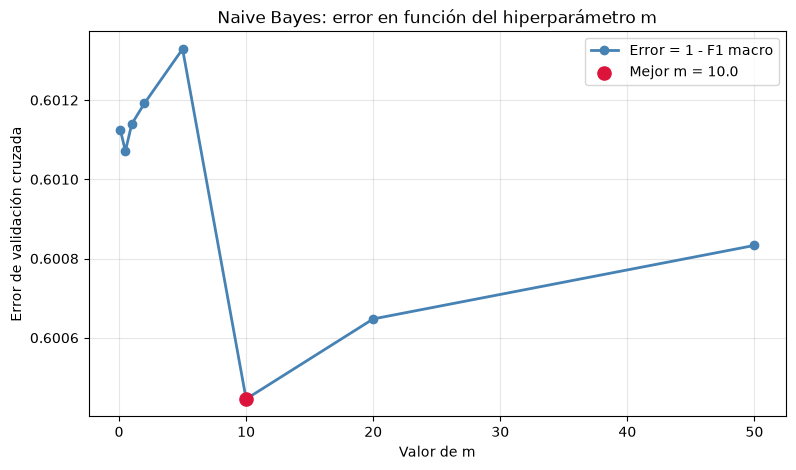

,m,f1_macro_promedio,error_f1_macro
0,0.1,0.398875,0.601125
1,0.5,0.398929,0.601071
2,1.0,0.398860,0.601140
3,2.0,0.398808,0.601192
4,5.0,0.398671,0.601329
5,10.0,0.399554,0.600446
6,20.0,0.399352,0.600648
7,50.0,0.399167,0.600833


In [217]:
import matplotlib.pyplot as plt

resultados_cv_ordenados = resultados_cv_df.sort_values('m').reset_index(drop=True).copy()
resultados_cv_ordenados['error_f1_macro'] = 1 - resultados_cv_ordenados['f1_macro_promedio']
mejor_fila_plot = resultados_cv_ordenados.loc[resultados_cv_ordenados['f1_macro_promedio'].idxmax()]

plt.figure(figsize=(9, 5))
plt.plot(
    resultados_cv_ordenados['m'],
    resultados_cv_ordenados['error_f1_macro'],
    marker='o',
    linewidth=2,
    color='steelblue',
    label='Error = 1 - F1 macro'
)
plt.scatter(
    mejor_fila_plot['m'],
    mejor_fila_plot['error_f1_macro'],
    color='crimson',
    s=90,
    zorder=3,
    label=f"Mejor m = {mejor_fila_plot['m']}"
)
plt.xlabel('Valor de m')
plt.ylabel('Error de validación cruzada')
plt.title('Naive Bayes: error en función del hiperparámetro m')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

resultados_cv_ordenados[['m', 'f1_macro_promedio', 'error_f1_macro']]


In [207]:
mejor_fila = resultados_cv_df.iloc[0]
mejor_m = mejor_fila['m']

print(f"Mejor hiperparámetro encontrado: m = {mejor_m}")
print(f"F1-macro promedio (CV): {mejor_fila['f1_macro_promedio']:.4f}")
print(f"Accuracy promedio (CV): {mejor_fila['accuracy_promedio']:.4f}")


Mejor hiperparámetro encontrado: m = 10.0
F1-macro promedio (CV): 0.3996
Accuracy promedio (CV): 0.4305


#### Entrenamiento final con el mejor `m` encontrado

Se reentrena el `NaiveBayes` propio con **todo** el conjunto de entrenamiento (sin folds) usando `mejor_m`, y se evalúa sobre el conjunto de evaluación real (2024-2025), para comparar contra el modelo baseline (`m=1.0`).


In [208]:
naive_bayes_optimizado = NaiveBayes(m=mejor_m)
naive_bayes_optimizado.fit(X_train_nb, Y_train)

predicciones_nb_optimizado = naive_bayes_optimizado.predict(X_test_nb)

print(f"Accuracy (m={mejor_m}):", accuracy_score(Y_test, predicciones_nb_optimizado))
print()
print(classification_report(Y_test, predicciones_nb_optimizado))
print("Matriz de confusión (orden de clases:", naive_bayes_optimizado.clases_, "):")
print(confusion_matrix(Y_test, predicciones_nb_optimizado, labels=naive_bayes_optimizado.clases_))


Accuracy (m=10.0): 0.45665961945031713

              precision    recall  f1-score   support

           E       0.36      0.23      0.28       132
           L       0.51      0.56      0.53       190
           V       0.45      0.52      0.48       151

    accuracy                           0.46       473
   macro avg       0.44      0.44      0.43       473
weighted avg       0.45      0.46      0.45       473

Matriz de confusión (orden de clases: ['E', 'L', 'V'] ):
[[ 31  53  48]
 [ 34 106  50]
 [ 22  50  79]]


#### ¿Es un buen predictor?

Por ahora el modelo mejoró respecto a las primeras versiones, sobre todo en la detección de empates, pero todavía no es un predictor fuerte.

- El objetivo principal ya no es solo subir `accuracy`, sino mejorar `f1_macro` para que las tres clases (`L`, `V`, `E`) tengan un desempeño más parejo.
- Los nuevos atributos recientes de victorias, empates y goles agregaron señal útil, especialmente para la clase `E`.
- Aun así, el modelo sigue confundiendo muchos empates con victorias locales o visitantes, así que todavía falta información de contexto entre ambos equipos.

---
### 7. Comparación con `CategoricalNB` de scikit-learn

`CategoricalNB` no acepta strings ni one-hot: necesita una **codificación ordinal** (enteros 0..k-1 por columna). Además, a diferencia de nuestro `NaiveBayes` propio, no maneja automáticamente valores no vistos en entrenamiento (equipos que solo aparecen en 2024-2025) — si aparece una categoría nueva en `predict`, falla.

Para resolverlo de forma equivalente a nuestro `respaldo_categoricas_`:

* Se usa `OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=k)`, reservando un índice extra (`k`) por columna para valores no vistos en entrenamiento.
* Se le informa a `CategoricalNB` esa cantidad real de categorías por columna vía `min_categories`, para que reserve espacio (y probabilidad suavizada) para ese valor "desconocido".
* Se usa `alpha=1.0` (suavizado Laplace estándar de sklearn) como punto de comparación "de fábrica". No es matemáticamente idéntico a nuestro `m` (la relación aproximada es `alpha ≈ m / cantidad_de_categorías`, que varía por columna ya que `home`/`away` tienen muchas más categorías que `full_time`), pero es conceptualmente análogo: ambos suavizan las probabilidades para evitar ceros.


In [218]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

X_train_ord = X_train_nb.copy()
X_test_ord = X_test_nb.copy()
cantidad_categorias = []

for columna in atributos_naive_bayes:
    categorias_train = sorted(X_train_nb[columna].unique())
    valor_desconocido = len(categorias_train)  # índice reservado para valores no vistos en entrenamiento

    encoder = OrdinalEncoder(
        categories=[categorias_train],
        handle_unknown='use_encoded_value',
        unknown_value=valor_desconocido,
    )
    X_train_ord[columna] = encoder.fit_transform(X_train_nb[[columna]])
    X_test_ord[columna] = encoder.transform(X_test_nb[[columna]])
    cantidad_categorias.append(valor_desconocido + 1)

categorical_nb = CategoricalNB(alpha=1.0, min_categories=cantidad_categorias)
categorical_nb.fit(X_train_ord, Y_train)

predicciones_categorical_nb = categorical_nb.predict(X_test_ord)
predicciones_categorical_nb[:5]


array(['L', 'V', 'V', 'V', 'E'], dtype='<U1')

In [200]:
print("Accuracy:", accuracy_score(Y_test, predicciones_categorical_nb))
print()
print(classification_report(Y_test, predicciones_categorical_nb))
print("Matriz de confusión (orden de clases:", list(categorical_nb.classes_), "):")
print(confusion_matrix(Y_test, predicciones_categorical_nb, labels=categorical_nb.classes_))


Accuracy: 0.46511627906976744

              precision    recall  f1-score   support

           E       0.35      0.25      0.29       132
           L       0.51      0.55      0.53       190
           V       0.47      0.54      0.50       151

    accuracy                           0.47       473
   macro avg       0.45      0.45      0.44       473
weighted avg       0.45      0.47      0.46       473

Matriz de confusión (orden de clases: [np.str_('E'), np.str_('L'), np.str_('V')] ):
[[ 33  53  46]
 [ 39 105  46]
 [ 21  48  82]]


In [219]:
from sklearn.metrics import f1_score, recall_score

comparacion = pd.DataFrame([
    {
        'modelo': 'NaiveBayes propio (m=mejor_m)',
        'accuracy': accuracy_score(Y_test, predicciones_nb_optimizado),
        'f1_macro': f1_score(Y_test, predicciones_nb_optimizado, average='macro'),
        'recall_E': recall_score(Y_test, predicciones_nb_optimizado, labels=['E'], average='macro'),
    },
    {
        'modelo': 'CategoricalNB (sklearn, alpha=1.0)',
        'accuracy': accuracy_score(Y_test, predicciones_categorical_nb),
        'f1_macro': f1_score(Y_test, predicciones_categorical_nb, average='macro'),
        'recall_E': recall_score(Y_test, predicciones_categorical_nb, labels=['E'], average='macro'),
    },
])
comparacion


,modelo,accuracy,f1_macro,recall_E
0,NaiveBayes propio (m=mejor_m),0.45666,0.432047,0.234848
1,"CategoricalNB (sklearn, alpha=1.0)",0.45666,0.432047,0.234848


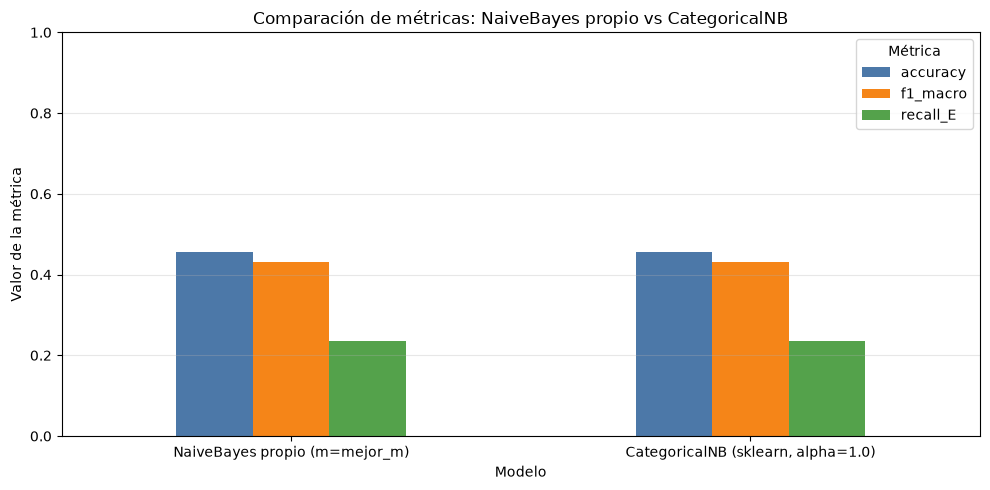

,accuracy,f1_macro,recall_E
modelo,,,
NaiveBayes propio (m=mejor_m),0.45666,0.432047,0.234848
"CategoricalNB (sklearn, alpha=1.0)",0.45666,0.432047,0.234848


In [220]:
metricas_plot = comparacion.set_index('modelo')[['accuracy', 'f1_macro', 'recall_E']]

ax = metricas_plot.plot(
    kind='bar',
    figsize=(10, 5),
    rot=0,
    color=['#4C78A8', '#F58518', '#54A24B']
)
ax.set_title('Comparación de métricas: NaiveBayes propio vs CategoricalNB')
ax.set_ylabel('Valor de la métrica')
ax.set_xlabel('Modelo')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

metricas_plot


#### Conclusión de la comparación

Hasta ahora, los dos modelos de Naive Bayes quedan bastante cerca entre sí, pero la comparación ya no sirve solo para validar implementación: ahora también sirve para medir cuánto ayudan los nuevos atributos.

- El `NaiveBayes` propio mejoró su `f1_macro` y su recall para empates al incorporar atributos recientes de resultados y goles.
- `CategoricalNB` sigue siendo la referencia directa de sklearn para verificar que el comportamiento general del modelo propio sea razonable.
- Si ambos modelos vuelven a quedar muy parecidos, eso refuerza la idea de que el límite actual está en los atributos disponibles y no en la implementación.
- La línea de mejora más prometedora pasa por seguir agregando atributos de fuerza relativa entre local y visitante, por ejemplo diferencia de gol reciente, puntos recientes o head-to-head, y no por seguir ajustando solo el hiperparámetro `m`.